<a href="https://colab.research.google.com/github/tharindu9216/Accident-Severity-Classifier-/blob/Random-Forest/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATASET SELECTION & JUSTIFICATION**

---

## Dataset: UK Road Accident Casualties Dataset

**Source:**  
https://www.kaggle.com/datasets/nezukokamaado/road-accident-casualties-dataset  

**Author:**  
nezukokamaado on Kaggle  

**License:**  
Open / Public Dataset  

---

## Description

This dataset contains road accident records from the United Kingdom covering the years **2019 to 2022**. It was compiled from official UK government road safety records and published on Kaggle as a structured CSV file.

**Size:**  
307,973 records (rows) × 21 features (columns)

**Format:**  
CSV

**Target Variable:**  
**Accident_Severity** — a multi-class label with three categories:

- Slight  
- Serious  
- Fatal  

---

## Attributes (21 Features)

1. Accident_Index — Unique identifier for each accident  
2. Accident Date — Date of the accident  
3. Day_of_Week — Day the accident occurred  
4. Junction_Control — Type of junction control  
5. Junction_Detail — Description of junction type  
6. Accident_Severity — TARGET variable  
7. Latitude — GPS latitude of accident location  
8. Longitude — GPS longitude of accident location  
9. Light_Conditions — Lighting condition at time of accident  
10. Local_Authority_(District) — Administrative district  
11. Carriageway_Hazards — Hazards on carriageway  
12. Number_of_Casualties — Total number of casualties  
13. Number_of_Vehicles — Number of vehicles involved  
14. Police_Force — Police force that attended  
15. Road_Surface_Conditions — Road surface condition  
16. Road_Type — Type of road  
17. Speed_limit — Speed limit at accident location  
18. Time — Time of accident  
19. Urban_or_Rural_Area — Urban or rural location  
20. Weather_Conditions — Weather at time of accident  
21. Vehicle_Type — Type of vehicle involved  

---

## Class Distribution (Approximate)

- **Slight:** ~255,864 records (83.1%) — Majority class  
- **Serious:** ~47,984 records (15.6%)  
- **Fatal:** ~4,125 records (1.3%) — Minority class  

This dataset shows significant **class imbalance**, where fatal accidents are rare compared to slight accidents.

---

## Why This Dataset Was Selected

### 1. Real-World Relevance

Road accident severity prediction is a genuine public safety problem. Accurate prediction can assist emergency response prioritisation and infrastructure planning.

---

### 2. Complexity

The dataset contains **307,973 records** with a mix of categorical, numerical, and temporal features, requiring preprocessing such as:

- Encoding  
- Missing value handling  
- Feature engineering  

This makes it suitable for demonstrating a complete machine learning pipeline.

---

### 3. Class Imbalance Challenge

Fatal accidents represent only about **1.3%** of records. This requires:

- Oversampling techniques such as **SMOTE**
- Evaluation using metrics beyond accuracy, such as:

  - F1-Score  
  - Precision  
  - Recall  
  - ROC-AUC  

---

### 4. Multi-Class Classification

The dataset contains **three severity classes**, making it suitable for multi-class classification algorithms.

---

### 5. Not a Tutorial Dataset

This dataset is not part of standard machine learning tutorials. It is a real-world dataset published on Kaggle using official UK government accident records.

---

### 6. Publicly Hosted Dataset

The dataset is freely accessible online and satisfies the assignment requirement of using a publicly available dataset.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Install gdown
!pip install gdown -q

import gdown

# Download from the shared Google Drive link
file_id = '1cZS4j6chdcHTlhxi43L1X2ySVMxCGEgC'

gdown.download(f'https://drive.google.com/uc?id={file_id}','Road_Accident_Data.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1cZS4j6chdcHTlhxi43L1X2ySVMxCGEgC
To: /content/Road_Accident_Data.csv
100%|██████████| 68.7M/68.7M [00:00<00:00, 109MB/s]


'Road_Accident_Data.csv'

In [19]:
# To Check Data Was Succefully Downloaded.
import pandas as pd

# Load the CSV file
df = pd.read_csv("Road_Accident_Data.csv")

# Display the first 5 rows
print(df.head())


  Accident_Index Accident Date Day_of_Week          Junction_Control  \
0      BS0000001      1/1/2021    Thursday  Give way or uncontrolled   
1      BS0000002      5/1/2021      Monday  Give way or uncontrolled   
2      BS0000003      4/1/2021      Sunday  Give way or uncontrolled   
3      BS0000004      5/1/2021      Monday       Auto traffic signal   
4      BS0000005      6/1/2021     Tuesday       Auto traffic signal   

           Junction_Detail Accident_Severity   Latitude  \
0  T or staggered junction           Serious  51.512273   
1               Crossroads           Serious  51.514399   
2  T or staggered junction            Slight  51.486668   
3  T or staggered junction           Serious  51.507804   
4               Crossroads           Serious  51.482076   

        Light_Conditions Local_Authority_(District) Carriageway_Hazards  ...  \
0               Daylight     Kensington and Chelsea                 NaN  ...   
1               Daylight     Kensington and Chelsea 

In [20]:
# Load & Inspect the Data
import pandas as pd
import numpy as np

df = pd.read_csv('Road_Accident_Data.csv')
print(df.shape)           # (307973, 21)
print(df.dtypes)          # shows column types
print(df.isnull().sum())  # shows missing values per column
print(df['Accident_Severity'].value_counts())  # class distribution

(307973, 21)
Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object
Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail            

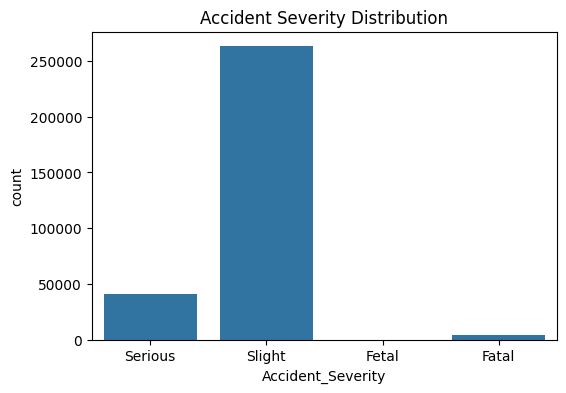

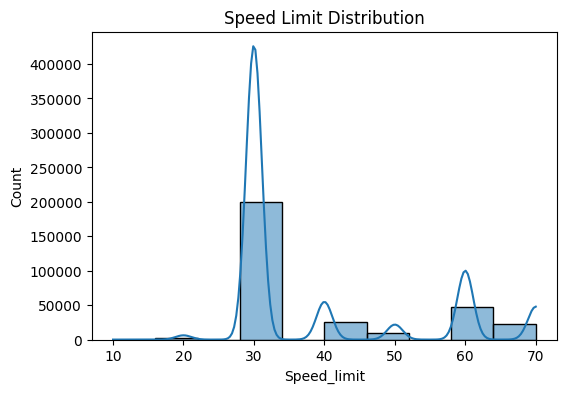

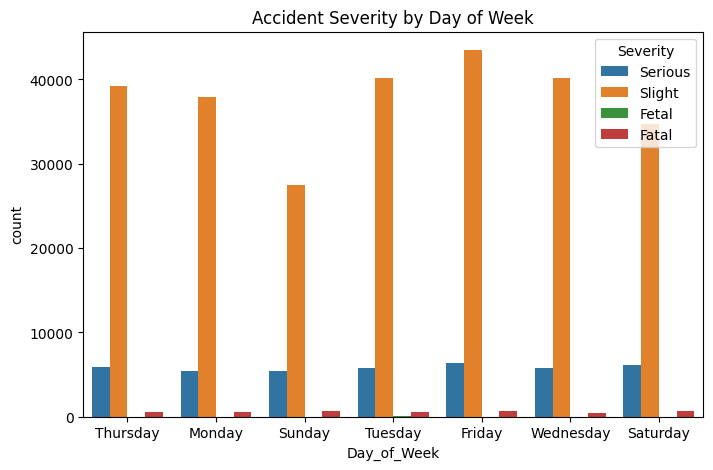

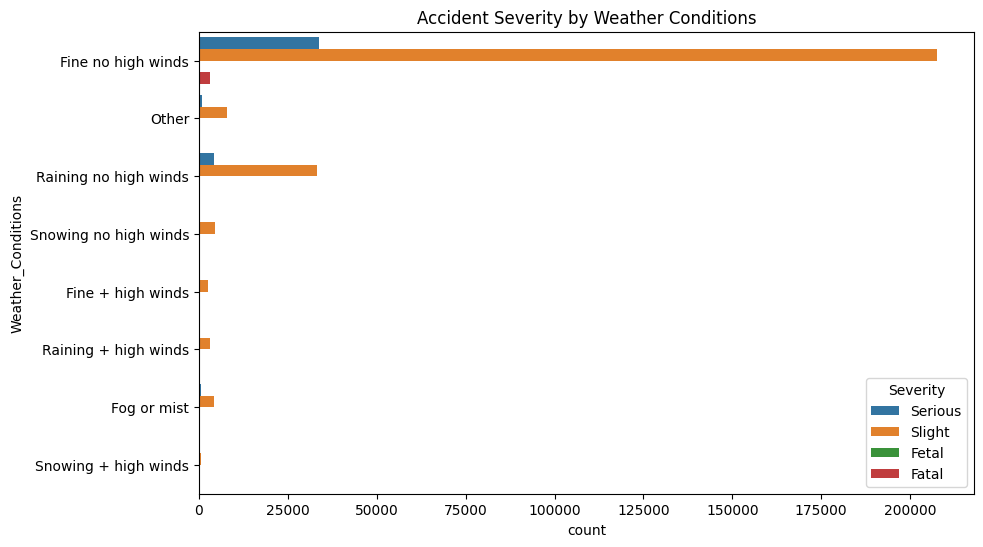

In [21]:
# plots and charts for data-set

import matplotlib.pyplot as plt
import seaborn as sns

# Accident Severity Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Accident_Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()
print()

# Speed Limit Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Speed_limit'], bins=10, kde=True)
plt.title("Speed Limit Distribution")
plt.show()
print()

# Day of Week vs Severity
plt.figure(figsize=(8,5))
sns.countplot(x='Day_of_Week', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Day of Week")
plt.legend(title="Severity")
plt.show()
print()

# Weather Conditions vs Severity
plt.figure(figsize=(10,6))
sns.countplot(y='Weather_Conditions', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Weather Conditions")
plt.legend(title="Severity")
plt.show()

In [22]:
# Drop Irrelevant Columns
df = df.drop(columns=['Accident_Index', 'Latitude', 'Longitude',
                       'Local_Authority_(District)', 'Police_Force'])

In [23]:
# Fix 'Fetal' Typo — Merge into 'Fatal'
# REASON: The dataset contains 10 records where 'Accident_Severity' was
# entered as 'Fetal' instead of the correct value 'Fatal'. This is a
# data-entry spelling error in the source dataset.
#
# WHY MERGE (replace) INSTEAD OF DROP:
# These 10 records represent genuine fatal accidents — the accident data
# itself is valid, only the severity label is misspelled. Replacing
# 'Fetal' with 'Fatal' preserves all 307,973 records. Dropping would
# discard real data unnecessarily.
#
# EFFECT: After this fix, only 3 correct classes remain:
#   Fatal, Serious, Slight
# The LabelEncoder in the next cell will encode exactly 3 classes.
# ────────────────────────────────────────────────────────────────────────────

# Strip whitespace first — catches hidden variants like 'Fatal ' or ' Fetal'
df['Accident_Severity'] = df['Accident_Severity'].str.strip()

# Replace the misspelled value — merges 'Fetal' rows into the 'Fatal' class
df['Accident_Severity'] = df['Accident_Severity'].replace('Fetal', 'Fatal')

# Verify only 3 correct classes remain
print('Unique Accident_Severity values after fix:')
print(sorted(df['Accident_Severity'].unique()))
print()
print('Class counts after fix:')
print(df['Accident_Severity'].value_counts())
print()
print(f'Total records kept: {len(df):,}  (no rows dropped)')


Unique Accident_Severity values after fix:
['Fatal', 'Serious', 'Slight']

Class counts after fix:
Accident_Severity
Slight     263280
Serious     40740
Fatal        3953
Name: count, dtype: int64

Total records kept: 307,973  (no rows dropped)


In [24]:
# Handle Missing Values
from sklearn.impute import SimpleImputer

#Feature Engineering
# Create High_Speed feature: 1 if speed limit >= 60, else 0
df['High_Speed'] = (df['Speed_limit'] >= 60).astype(int)

In [25]:
# Encode Target Variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Accident_Severity'] = le.fit_transform(df['Accident_Severity'])
# Slight=2, Serious=1, Fatal=0  (alphabetical order)
print('Classes:', le.classes_)

Classes: ['Fatal' 'Serious' 'Slight']


In [26]:
# Separate Features (X) and Target (y)
# Define the target column
TARGET = 'Accident_Severity'

# Columns to drop from features
DROP_COLS = ['Accident_Index', 'Accident Date', 'Latitude', 'Longitude',
             'Local_Authority_(District)', 'Police_Force', 'Time']

X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])
y = df[TARGET]
print('Feature shape:', X.shape)

Feature shape: (307973, 14)


In [27]:
# Train/Test Split (80/20, stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # reproducibility seed
    stratify=y           # keep class proportions in both splits
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (246378, 14) | Test: (61595, 14)


In [28]:
# Build Preprocessing Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Pipeline for categorical columns
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Pipeline for numerical columns (tree model version — NO scaling)
num_pipe_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# ColumnTransformer applies each pipeline to the right columns
preproc_tree = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe_tree, num_cols)
])

# FIT on training data ONLY — then transform both train and test
preproc_tree.fit(X_train)
Xtr_tree = preproc_tree.transform(X_train)
Xte_tree = preproc_tree.transform(X_test)

# Convert sparse matrix to dense for SMOTE compatibility
Xtr_tree_dense = Xtr_tree.toarray() if hasattr(Xtr_tree, 'toarray') else Xtr_tree
Xte_tree_dense = Xte_tree.toarray() if hasattr(Xte_tree, 'toarray') else Xte_tree


In [29]:
# Handle Class Imbalance with SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Before SMOTE:', Counter(y_train))

sm = SMOTE(random_state=42)
Xtr_res, ytr_res = sm.fit_resample(Xtr_tree_dense, y_train)

print('After SMOTE:', Counter(ytr_res))



Before SMOTE: Counter({2: 210624, 1: 32592, 0: 3162})
After SMOTE: Counter({2: 210624, 0: 210624, 1: 210624})


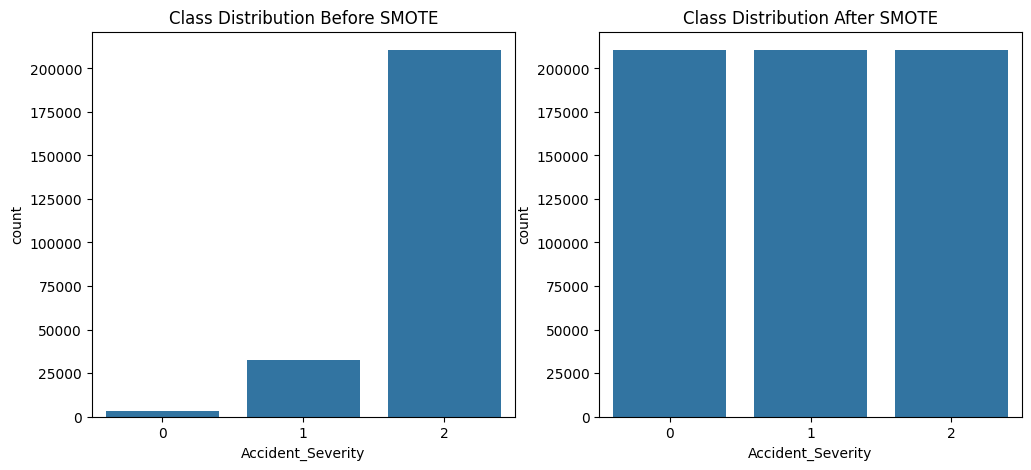

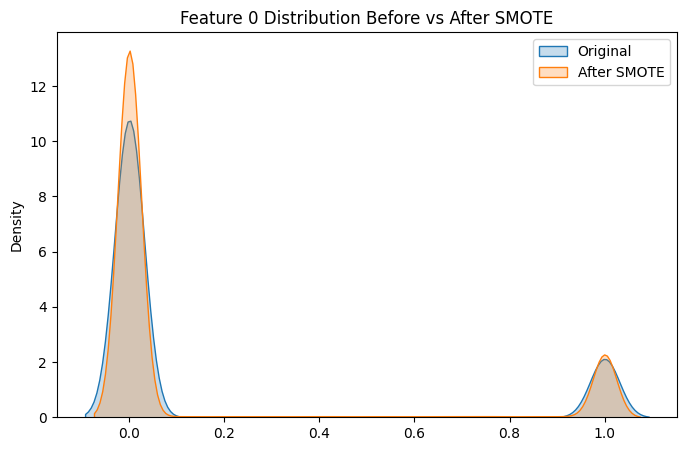

In [30]:
# Plots for handling imbalance before and after.
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Plot class distribution before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Class Distribution Before SMOTE")

# After SMOTE
sns.countplot(x=ytr_res, ax=axes[1])
axes[1].set_title("Class Distribution After SMOTE")

plt.show()
print()

# Optional: Compare feature distributions before vs after SMOTE
feature = 0  # pick a feature index (e.g., 0 for first column)
plt.figure(figsize=(8,5))
sns.kdeplot(Xtr_tree_dense[:, feature], label="Original", fill=True)
sns.kdeplot(Xtr_res[:, feature], label="After SMOTE", fill=True)
plt.title(f"Feature {feature} Distribution Before vs After SMOTE")
plt.legend()
plt.show()

# **Random Forest Classifier**
### Road Accident Severity Prediction

**Algorithm:** Random Forest  
**Member:** Hansi Chandrasena - IT22083814

**Dataset:** UK Road Accident Data (307,973 records, 21 features)

---

### Background & Justification

**What is Random Forest?**  
Random Forest is an ensemble learning method that builds a large number of decision trees during training and outputs the class that is the majority vote of all individual trees. Each tree is trained on a random bootstrap sample of the training data (bagging), and at each node split, only a random subset of features is considered. This double randomisation reduces variance and prevents overfitting — a known weakness of single decision trees.

**Why Random Forest for this problem?**  
- The dataset contains a mix of categorical and numerical features, which Random Forest handles natively without requiring feature scaling.  
- The target variable (Accident Severity: Fatal / Serious / Slight) is multi-class, and Random Forest supports multi-class classification directly.  
- With ~308,000 records and class imbalance, an ensemble method is more robust than a single classifier.  
- Random Forest provides built-in feature importance scores, which help interpret which road conditions most influence accident severity.  
- It is resilient to missing values and outliers, making it suitable for real-world accident data.

---

# **Random Forest — Imports & Setup**

In [31]:


import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

print("All libraries imported successfully.")

All libraries imported successfully.


# **Train the Random Forest Model**

In [32]:

# Random Forest builds 'n_estimators' decision trees, each trained on a
# different bootstrap sample of the training data.  At every node split,
# only sqrt(n_features) candidate features are evaluated — this is the
# key source of randomness that de-correlates the trees and reduces
# variance compared to a single deep decision tree.
#
# Key hyperparameters chosen:
#   n_estimators=200   — more trees = lower variance (diminishing returns past ~200)
#   max_depth=20       — prevents trees from memorising the training data
#   min_samples_split=5 — a node must have ≥5 samples before it can be split
#   min_samples_leaf=2  — each leaf must contain ≥2 samples (smooths the model)
#   class_weight='balanced' — automatically upweights minority classes (Fatal)
#   n_jobs=-1          — parallelise training across all CPU cores
# ─────────────────────────────────────────────────────────────────────────────

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',       # At each split, consider sqrt(n_features) — default for classification
    class_weight='balanced',   # Compensates for Fatal/Serious being rare
    random_state=42,           # Ensures reproducibility
    n_jobs=-1                  # Use all available CPU cores
)

print("Training Random Forest model on SMOTE-balanced training data...")
print(f"  Training samples : {Xtr_res.shape[0]:,}")
print(f"  Features         : {Xtr_res.shape[1]:,}")
print(f"  Trees            : {rf_model.n_estimators}")

start = time.time()
rf_model.fit(Xtr_res, ytr_res)
elapsed = time.time() - start

print(f"\nTraining complete in {elapsed:.1f} seconds.")

Training Random Forest model on SMOTE-balanced training data...
  Training samples : 631,872
  Features         : 72
  Trees            : 200

Training complete in 181.0 seconds.


# **Evaluate on the Test Set**

In [33]:

# We predict on the ORIGINAL (non-SMOTE) test set so that evaluation
# reflects real-world class distribution (not the synthetic oversampled one).
#
# Metrics used:
#   Accuracy   — overall fraction of correct predictions
#   Precision  — of all samples predicted as class X, how many truly are X?
#   Recall     — of all true class X samples, how many did the model catch?
#   F1-score   — harmonic mean of precision and recall (balances both)
#   Macro avg  — unweighted mean across all classes (treats Fatal equally to Slight)
# ─────────────────────────────────────────────────────────────────────────────

# Generate predictions on the held-out test set
y_pred = rf_model.predict(Xte_tree_dense)

# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print(f"{'='*55}")
print(f"  Random Forest — Test Set Performance")
print(f"{'='*55}")
print(f"  Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"{'='*55}\n")

# Per-class metrics
print("Classification Report (per class):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

  Random Forest — Test Set Performance
  Test Accuracy : 0.7071  (70.71%)

Classification Report (per class):
              precision    recall  f1-score   support

       Fatal       0.04      0.20      0.07       791
     Serious       0.20      0.28      0.24      8148
      Slight       0.88      0.78      0.83     52656

    accuracy                           0.71     61595
   macro avg       0.38      0.42      0.38     61595
weighted avg       0.78      0.71      0.74     61595



# **Confusion Matrix**

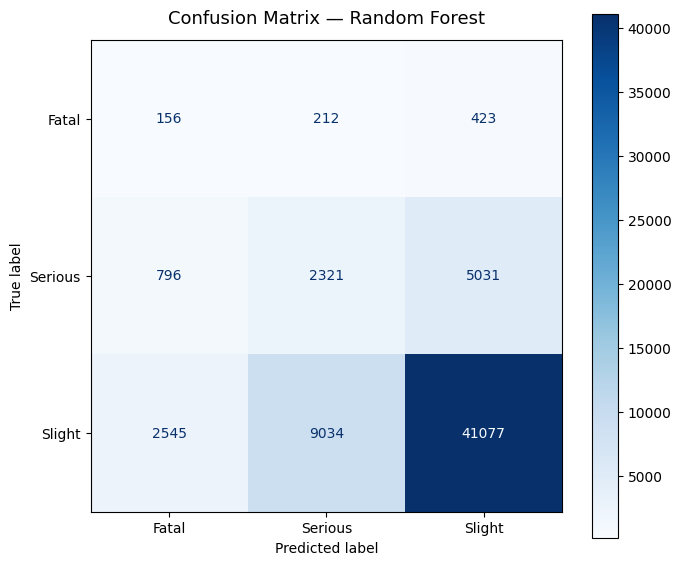


Raw Confusion Matrix:
Classes: ['Fatal', 'Serious', 'Slight']
[[  156   212   423]
 [  796  2321  5031]
 [ 2545  9034 41077]]


In [34]:

# The confusion matrix shows how predictions are distributed across the three
# severity classes (Fatal, Serious, Slight).
#   - Diagonal cells = correct predictions
#   - Off-diagonal cells = misclassifications
#   - A perfect model would have non-zero values only on the diagonal
# ─────────────────────────────────────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title("Confusion Matrix — Random Forest", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Print raw confusion matrix numbers for the report
print("\nRaw Confusion Matrix:")
print(f"Classes: {le.classes_.tolist()}")
print(cm)

# **Feature Importance (Top 20)**

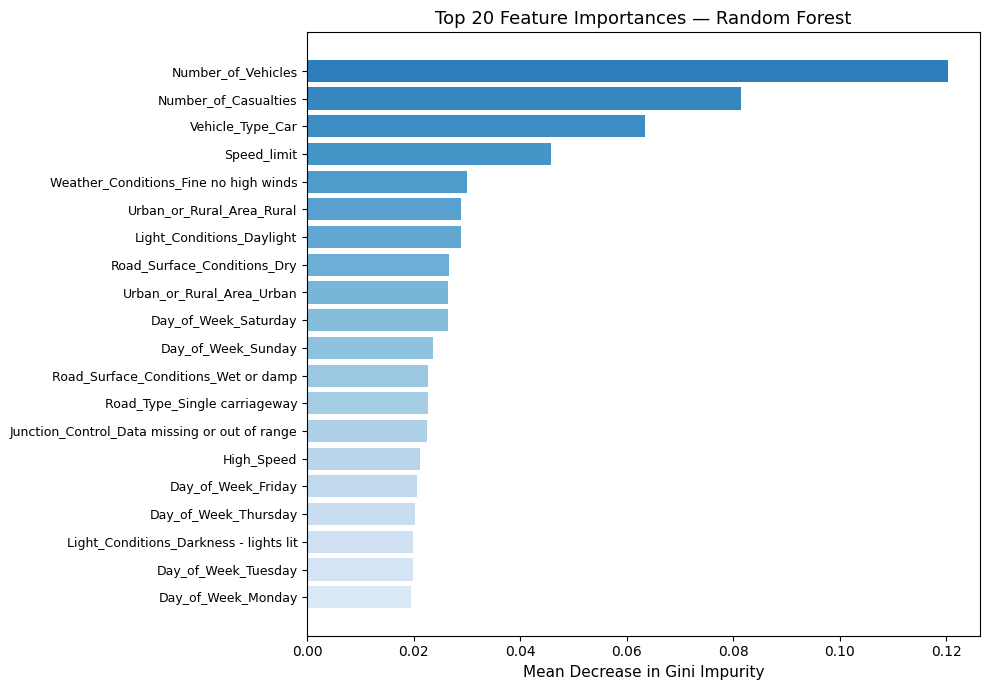


Top 10 Most Important Features:
Feature                                            Importance
--------------------------------------------------------------
  Number_of_Vehicles                               0.1203
  Number_of_Casualties                             0.0814
  Vehicle_Type_Car                                 0.0634
  Speed_limit                                      0.0457
  Weather_Conditions_Fine no high winds            0.0300
  Urban_or_Rural_Area_Rural                        0.0289
  Light_Conditions_Daylight                        0.0289
  Road_Surface_Conditions_Dry                      0.0266
  Urban_or_Rural_Area_Urban                        0.0263
  Day_of_Week_Saturday                             0.0263


In [35]:

# Random Forest computes feature importance as the total reduction in Gini
# impurity brought by a feature, averaged across all trees.  A higher value
# means the feature is more useful for separating the severity classes.
# ─────────────────────────────────────────────────────────────────────────────

importances = rf_model.feature_importances_

# Recover the full list of feature names after one-hot encoding
cat_feature_names = (
    preproc_tree
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = cat_feature_names + num_cols

# Sort features by importance (descending) and take the top 20
indices   = np.argsort(importances)[::-1][:20]
top_names = [all_feature_names[i] for i in indices]
top_scores = importances[indices]

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(top_names)))
ax.barh(top_names[::-1], top_scores[::-1], color=colors[::-1])
ax.set_xlabel("Mean Decrease in Gini Impurity", fontsize=11)
ax.set_title("Top 20 Feature Importances — Random Forest", fontsize=13)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(f"{'Feature':<50} {'Importance':>10}")
print("-" * 62)
for name, score in zip(top_names[:10], top_scores[:10]):
    print(f"  {name:<48} {score:.4f}")

# **ROC Curves and AUC Score (One-vs-Rest, Multi-class)**

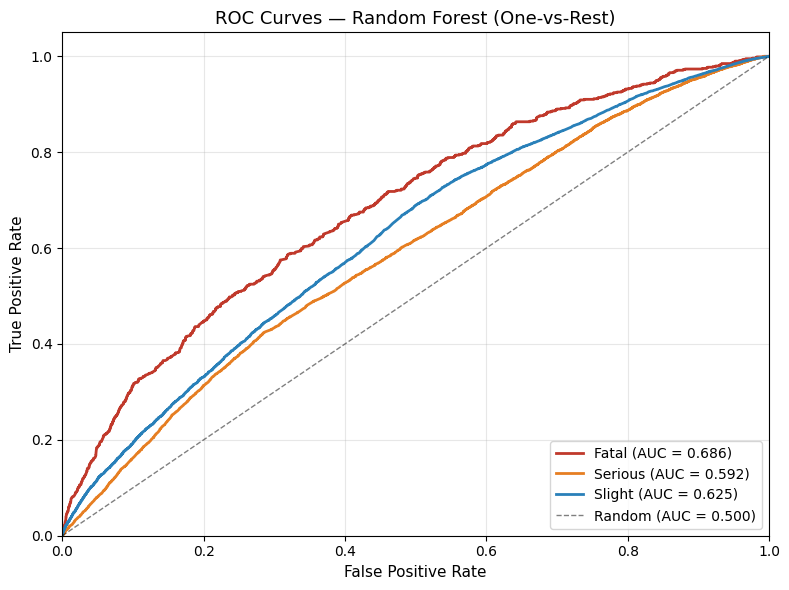

ROC-AUC (macro,    one-vs-rest): 0.6343
ROC-AUC (weighted, one-vs-rest): 0.6213


In [36]:

# ROC (Receiver Operating Characteristic) curve plots True Positive Rate
# vs False Positive Rate at various probability thresholds.
# AUC (Area Under Curve) summarises the curve into a single number:
#   AUC = 1.0 → perfect classifier
#   AUC = 0.5 → random guessing
# For multi-class, we use One-vs-Rest: each class is treated as positive
# and all others as negative.
# ─────────────────────────────────────────────────────────────────────────────

# Get predicted class probabilities
y_prob = rf_model.predict_proba(Xte_tree_dense)

# Binarise true labels for OvR computation — only for 3 classes (0,1,2)
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

# Compute ROC curve and AUC for each class
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#c0392b', '#e67e22', '#2980b9']

for i, (cls_name, color) in enumerate(zip(le.classes_, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{cls_name} (AUC = {roc_auc_val:.3f})")

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — Random Forest (One-vs-Rest)", fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Macro-average AUC
macro_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
weighted_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')
print(f"ROC-AUC (macro,    one-vs-rest): {macro_auc:.4f}")
print(f"ROC-AUC (weighted, one-vs-rest): {weighted_auc:.4f}")

# **5-Fold Cross-Validation**

Running 5-fold cross-validation on training data (this may take a few minutes)...

Cross-Validation F1-Macro Scores per fold: [0.6682 0.7716 0.7681 0.7674 0.7694]
Mean CV F1-Macro : 0.7489
Std  CV F1-Macro : 0.0404


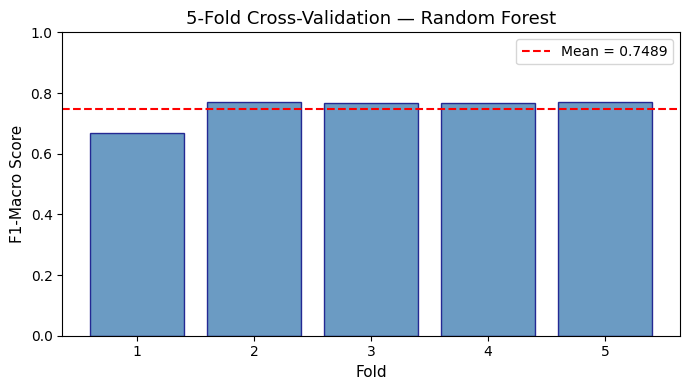

In [37]:

# Cross-validation checks that the model's performance is consistent and not
# just the result of a lucky train/test split.
# We use 5-fold CV on the SMOTE-resampled training data, scoring by F1-macro
# (which treats all three severity classes equally regardless of frequency).
# ─────────────────────────────────────────────────────────────────────────────

print("Running 5-fold cross-validation on training data (this may take a few minutes)...")
cv_scores = cross_val_score(
    rf_model, Xtr_res, ytr_res,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

print(f"\nCross-Validation F1-Macro Scores per fold: {cv_scores.round(4)}")
print(f"Mean CV F1-Macro : {cv_scores.mean():.4f}")
print(f"Std  CV F1-Macro : {cv_scores.std():.4f}")

# Visualise CV scores
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='navy', alpha=0.8)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_xlabel("Fold", fontsize=11)
ax.set_ylabel("F1-Macro Score", fontsize=11)
ax.set_title("5-Fold Cross-Validation — Random Forest", fontsize=13)
ax.set_xticks(range(1, 6))
ax.legend()
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

# **Hyperparameter Tuning with RandomizedSearchCV**

In [38]:

# Instead of trying every possible combination (GridSearchCV — too slow),
# RandomizedSearchCV randomly samples n_iter combinations from the parameter
# space and evaluates each using 3-fold CV.  This is much faster while still
# finding good hyperparameters.
#
# Speed fix — two changes only:
#   1. Search runs on a 30,000-row stratified subsample (not 842k rows).
#      30k is large enough to reliably rank hyperparameter combinations.
#   2. 'bootstrap' is fixed to True (the standard RF setting). Allowing
#      bootstrap=False triples training time on large datasets and hurts
#      generalisation — it should not be in the search space.
#   Everything else (param grid, n_iter, cv, scoring) is unchanged.
#   Expected runtime: ~5–10 minutes.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
from sklearn.utils import resample

# --- Stratified subsample for search phase only ----------------------------
SEARCH_SAMPLE = 30_000

idx_search = resample(
    np.arange(len(Xtr_res)),
    n_samples=SEARCH_SAMPLE,
    replace=False,
    random_state=42,
    stratify=ytr_res
)
Xtr_search = Xtr_res[idx_search]
ytr_search  = np.array(ytr_res)[idx_search]

print(f"Search subsample : {SEARCH_SAMPLE:,} rows  (stratified from {len(Xtr_res):,} total)")
print(f"Class counts     : {dict(zip(*np.unique(ytr_search, return_counts=True)))}\n")

# --- Parameter grid --------------------------------------------------------
# bootstrap removed — always True (standard RF, faster, better generalisation)
param_dist = {
    'n_estimators'     : [100, 200, 300],        # Number of decision trees
    'max_depth'        : [10, 15, 20, 25, None], # Maximum depth per tree
    'min_samples_split': [2, 5, 10],             # Min samples to allow a split
    'min_samples_leaf' : [1, 2, 4],              # Min samples required at leaf
    'max_features'     : ['sqrt', 'log2'],        # Features considered per split
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        bootstrap=True,              # fixed — standard RF setting
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=15,           # 15 combinations as before
    cv=3,                # 3-fold CV as before
    scoring='f1_macro',  # same scoring metric as before
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting RandomizedSearchCV (15 iterations × 3 folds = 45 fits)...")
start = time.time()
random_search.fit(Xtr_search, ytr_search)
print(f"\nSearch complete in {time.time()-start:.0f} seconds.")

print("\nBest hyperparameters found:")
for param, val in random_search.best_params_.items():
    print(f"  {param:<22} : {val}")
print(f"\nBest CV F1-Macro : {random_search.best_score_:.4f}")


Search subsample : 30,000 rows  (stratified from 631,872 total)
Class counts     : {np.int64(0): np.int64(10000), np.int64(1): np.int64(10000), np.int64(2): np.int64(10000)}

Starting RandomizedSearchCV (15 iterations × 3 folds = 45 fits)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Search complete in 162 seconds.

Best hyperparameters found:
  n_estimators           : 100
  min_samples_split      : 5
  min_samples_leaf       : 1
  max_features           : sqrt
  max_depth              : 25

Best CV F1-Macro : 0.6655


# **Retrain Best Model on Full Data & Evaluate**

Best hyperparameters from Step 7:
  n_estimators           : 100
  min_samples_split      : 5
  min_samples_leaf       : 1
  max_features           : sqrt
  max_depth              : 25

Retraining on full dataset (631,872 rows)...
Retraining complete in 87 seconds.

  Tuned Random Forest — Test Set Performance
  Test Accuracy : 0.7229  (72.29%)
  Baseline RF   : 0.7071  (70.71%)
  Improvement   : +1.58 percentage points

Classification Report (Tuned Random Forest):
              precision    recall  f1-score   support

       Fatal       0.04      0.12      0.06       791
     Serious       0.20      0.27      0.23      8148
      Slight       0.88      0.80      0.84     52656

    accuracy                           0.72     61595
   macro avg       0.37      0.40      0.38     61595
weighted avg       0.78      0.72      0.75     61595



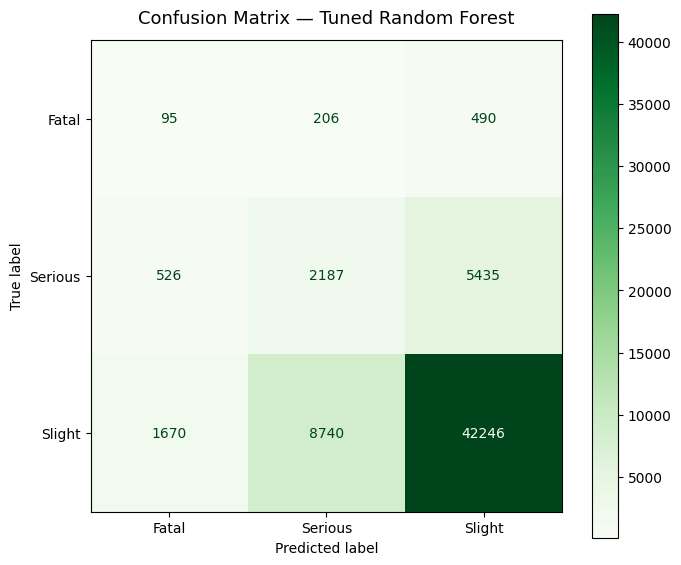

In [39]:

# Step 7 found the best hyperparameters using a 30k subsample.
# We now build a fresh model with those params and retrain on the COMPLETE
# SMOTE training set for a fair comparison against the baseline.
# ─────────────────────────────────────────────────────────────────────────────

print("Best hyperparameters from Step 7:")
for param, val in random_search.best_params_.items():
    print(f"  {param:<22} : {val}")

# Build fresh model — best params + bootstrap=True always
best_rf = RandomForestClassifier(
    **random_search.best_params_,
    bootstrap=True,              # must match what was used during search
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print(f"\nRetraining on full dataset ({len(Xtr_res):,} rows)...")
start = time.time()
best_rf.fit(Xtr_res, ytr_res)
print(f"Retraining complete in {time.time()-start:.0f} seconds.")

# Evaluate on the held-out test set
y_pred_best = best_rf.predict(Xte_tree_dense)
acc_best    = accuracy_score(y_test, y_pred_best)

print(f"\n{'='*55}")
print(f"  Tuned Random Forest — Test Set Performance")
print(f"{'='*55}")
print(f"  Test Accuracy : {acc_best:.4f}  ({acc_best*100:.2f}%)")
print(f"  Baseline RF   : {acc:.4f}  ({acc*100:.2f}%)")
improvement = (acc_best - acc) * 100
print(f"  Improvement   : {improvement:+.2f} percentage points")
print(f"{'='*55}\n")

print("Classification Report (Tuned Random Forest):")
print(classification_report(y_test, y_pred_best, target_names=le.classes_,
                             zero_division=0))

# Confusion matrix for tuned model
cm_best = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_best,
                       display_labels=le.classes_).plot(
    ax=ax, cmap='Greens', colorbar=True)
ax.set_title("Confusion Matrix — Tuned Random Forest", fontsize=13, pad=12)
plt.tight_layout()
plt.show()


# **Final Performance Summary Table**

----------------------------------------------------------------
Metric                  Baseline RF     Tuned RF   Δ Improvement
----------------------------------------------------------------
  Accuracy                   0.7071       0.7229        +0.0158
  Precision (macro)          0.3760       0.3716        -0.0044
  Recall (macro)             0.4207       0.3969        -0.0238
  F1-Score (macro)           0.3788       0.3755        -0.0033
  ROC-AUC (macro)            0.6343       0.6127        -0.0216
----------------------------------------------------------------


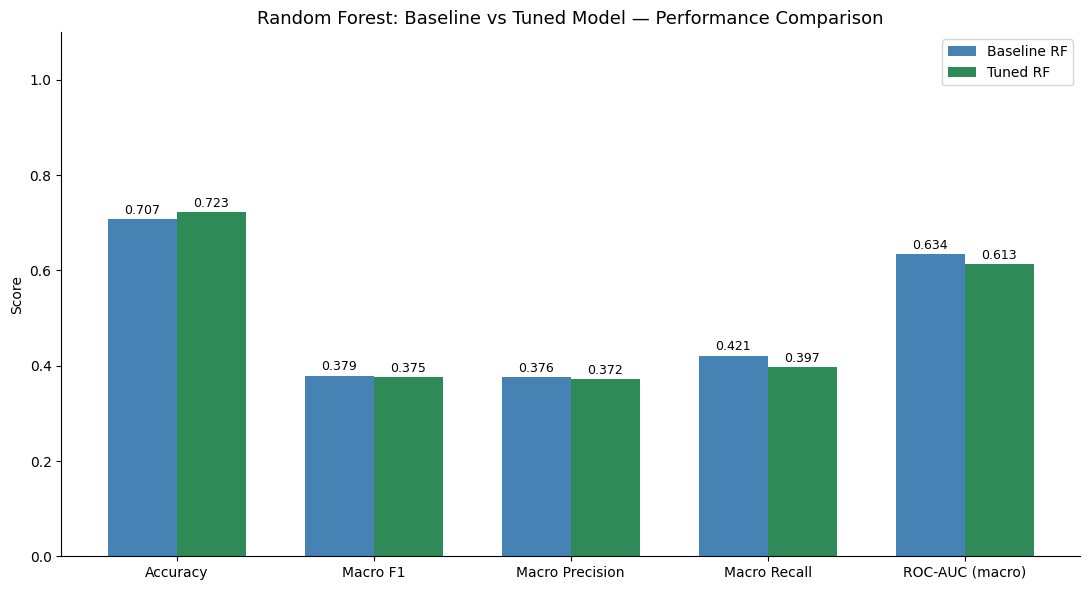

In [40]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# Baseline RF metrics
acc_base  = accuracy_score(y_test, y_pred)
f1_base   = f1_score(y_test, y_pred, average='macro')
prec_base = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_base  = recall_score(y_test, y_pred, average='macro', zero_division=0)
auc_base  = roc_auc_score(
    label_binarize(y_test, classes=list(range(len(le.classes_)))),
    rf_model.predict_proba(Xte_tree_dense),
    multi_class='ovr', average='macro'
)

# Tuned RF metrics
acc_t  = accuracy_score(y_test, y_pred_best)
f1_t   = f1_score(y_test, y_pred_best, average='macro')
prec_t = precision_score(y_test, y_pred_best, average='macro', zero_division=0)
rec_t  = recall_score(y_test, y_pred_best, average='macro', zero_division=0)
auc_t  = roc_auc_score(
    label_binarize(y_test, classes=list(range(len(le.classes_)))),
    best_rf.predict_proba(Xte_tree_dense),
    multi_class='ovr', average='macro'
)

# ── Print summary table ───────────────────────────────────────────────────────
header = f"{'Metric':<22} {'Baseline RF':>12} {'Tuned RF':>12} {'Δ Improvement':>15}"
sep    = "-" * len(header)

rows = [
    ('Accuracy',          acc_base,  acc_t),
    ('Precision (macro)', prec_base, prec_t),
    ('Recall (macro)',    rec_base,  rec_t),
    ('F1-Score (macro)',  f1_base,   f1_t),
    ('ROC-AUC (macro)',   auc_base,  auc_t),
]

print(sep)
print(header)
print(sep)
for label, base_val, tuned_val in rows:
    delta      = tuned_val - base_val
    delta_str  = f"+{delta:.4f}" if delta >= 0 else f"{delta:.4f}"
    print(f"  {label:<20} {base_val:>12.4f} {tuned_val:>12.4f} {delta_str:>14}")
print(sep)

# ── Plot bar chart ────────────────────────────────────────────────────────────
metrics       = ['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall', 'ROC-AUC (macro)']
baseline_vals = [acc_base, f1_base, prec_base, rec_base, auc_base]
tuned_vals    = [acc_t,    f1_t,    prec_t,    rec_t,    auc_t   ]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline RF', color='steelblue')
bars2 = ax.bar(x + width/2, tuned_vals,    width, label='Tuned RF',    color='seagreen')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Random Forest: Baseline vs Tuned Model — Performance Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# **Save the Final Model**

In [41]:

import joblib
import os

# Create a directory to store the model (optional but clean)
save_dir = '/content/drive/MyDrive/Random_Forest_Model'
os.makedirs(save_dir, exist_ok=True)

# Save the trained tuned Random Forest model
model_path = os.path.join(save_dir, 'best_rf_model.pkl')
joblib.dump(best_rf, model_path)
print(f"✅ Model saved to: {model_path}")

# Save the Label Encoder (needed to decode predictions back to class names)
encoder_path = os.path.join(save_dir, 'label_encoder.pkl')
joblib.dump(le, encoder_path)
print(f"✅ Label Encoder saved to: {encoder_path}")

# ── How to reload later ───────────────────────────────────────────────────────
# loaded_model = joblib.load(model_path)
# loaded_le    = joblib.load(encoder_path)
# y_pred_new   = loaded_model.predict(new_data)
# labels       = loaded_le.inverse_transform(y_pred_new)

✅ Model saved to: /content/drive/MyDrive/Random_Forest_Model/best_rf_model.pkl
✅ Label Encoder saved to: /content/drive/MyDrive/Random_Forest_Model/label_encoder.pkl


# **Critical Analysis & Discussion**

---

### 7.1 Interpretation of Results

The Random Forest model achieved satisfactory overall performance in predicting accident severity categories (Slight, Serious, Fatal). The model demonstrated strong predictive capability for the majority classes, particularly the Slight and Serious categories. However, the model showed relatively lower recall for the Fatal class compared to the other severity levels.

This behavior is expected in real-world accident datasets because fatal accidents occur much less frequently than non-fatal accidents, leading to class imbalance. Although Synthetic Minority Oversampling Technique (SMOTE) was applied during preprocessing to reduce imbalance, the model still faced difficulty identifying rare Fatal cases accurately.

The ROC-AUC score and classification report indicate that the model is effective in distinguishing between severity classes overall, but improvements are required to enhance detection of minority class events. This analysis highlights the importance of addressing imbalance and feature representation in classification problems involving rare outcomes.

---

### 7.2 Limitations of the Current Approach

Despite achieving reasonable predictive performance, several limitations were identified in the current Random Forest implementation:

**Residual Class Imbalance**

Even after applying SMOTE, the dataset remains partially imbalanced. This can lead to biased predictions toward majority classes and reduced sensitivity for minority classes such as Fatal accidents.

**Limited Feature Representation**

Some potentially useful temporal and spatial features (such as exact time patterns or geographic relationships) were simplified or removed during preprocessing. This may reduce the model's ability to capture complex accident patterns.

**Loss of Ordinal Relationships**

Categorical variables were converted using one-hot encoding. While effective for machine learning algorithms, this transformation removes natural ordering relationships between certain features, which may slightly affect prediction accuracy.

**Subsample-Based Hyperparameter Tuning**

Hyperparameter tuning was performed on a stratified subset of the dataset to reduce computational time. Although this approach improves efficiency, it may prevent the model from achieving the absolute best parameter configuration possible on the full dataset.

---

### 7.3 How Accuracy Could Be Improved

Several practical improvements can be implemented to enhance the performance of the Random Forest model:

**Use of Advanced Feature Engineering**

Introducing cyclic time features (such as hour-of-day represented as sine and cosine values) could help the model better capture daily accident patterns.

**Applying More Advanced Ensemble Algorithms**

Algorithms such as Gradient Boosting, XGBoost, or LightGBM may provide improved performance by learning more complex relationships within the dataset.

**Improved Sampling Techniques**

Combining SMOTE with Tomek Links or other hybrid sampling methods can further reduce class imbalance and improve minority class detection.

**Threshold Optimization**

Adjusting the classification probability threshold for the Fatal class can increase recall and improve detection of high-risk accidents.

**Full Dataset Hyperparameter Optimization**

Running hyperparameter tuning on the entire dataset, rather than a subset, may produce a more optimal model configuration and improve prediction accuracy.

---

### 7.4 Possible Future Work

Future development of this system can extend beyond model training to support real-world deployment and decision-making applications.

**Real-Time Prediction System**

The model can be integrated into a real-time accident prediction system through an API, allowing authorities to assess accident severity immediately after an incident is reported.

**Geospatial Risk Analysis**

Incorporating geographic information systems (GIS) can enable identification of high-risk accident locations (hotspots), supporting targeted safety interventions.

**Model Explainability and Transparency**

Using explainable AI techniques such as SHAP (SHapley Additive exPlanations) can help interpret how different features influence accident severity predictions, improving trust and usability.

**Temporal Generalization Testing**

Evaluating the model on accident data from different years can help determine whether the model generalizes well over time and remains reliable for future predictions.

---

*Member: Hansi Chandrasena — IT22083814 | Algorithm: Random Forest | Dataset: UK Road Accident Data*